In [3]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("data/complaints.csv")
df.head()

,Unnamed: 0,product_5,narrative,Product,Date received,Sub-product,Issue,Sub-issue,Company,State,Timely response?
0,234,Credit Reporting,Dear Possible Financial Inc you guyss aree rep...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Incorrect information on your report,Account information incorrect,Possible Financial Inc,MI,Yes
1,240,Debt Collection,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt collection,2024-07-27,I do not know,Threatened to contact someone or share informa...,Talked to a third-party about your debt,BlueChip Financial,TX,Yes
2,257,Credit Reporting,I been receiving alerts my information was fou...,Credit reporting or other personal consumer re...,2024-07-23,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,FC HoldCo LLC,SC,Yes
3,271,Credit Reporting,Subject : Dispute of Inaccurate Information on...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Improper use of your report,Reporting company used your report improperly,CORELOGIC INC,GA,Yes
4,276,Loans,They allowed me to use the account for about a...,"Payday loan, title loan, personal loan, or adv...",2024-07-26,Payday loan,Received a loan you didn't apply for,NaN,MoneyLion Inc.,PA,Yes


In [5]:
df = df[["narrative", "product_5"]]

In [6]:
df = df.rename(columns={
    "narrative": "text",
    "product_5": "label"
})

In [7]:
df.head()

,text,label
0,Dear Possible Financial Inc you guyss aree rep...,Credit Reporting
1,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt Collection
2,I been receiving alerts my information was fou...,Credit Reporting
3,Subject : Dispute of Inaccurate Information on...,Credit Reporting
4,They allowed me to use the account for about a...,Loans


In [8]:
df = df.dropna(subset=["text"])

In [9]:
df.head()

,text,label
0,Dear Possible Financial Inc you guyss aree rep...,Credit Reporting
1,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt Collection
2,I been receiving alerts my information was fou...,Credit Reporting
3,Subject : Dispute of Inaccurate Information on...,Credit Reporting
4,They allowed me to use the account for about a...,Loans


In [10]:
df.shape

(2023066, 2)

In [11]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'x+', '', text)
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["text"] = df["text"].apply(clean_text)


In [12]:
df.shape

(2023066, 2)

In [13]:
df["label"] = df["label"].str.lower().str.strip()

In [14]:
df.shape

(2023066, 2)

In [15]:
df = df.drop_duplicates()

In [16]:
df.shape

(1470537, 2)

In [17]:
df = df[df["text"].str.len() > 20]

In [18]:
df.shape

(1469802, 2)

In [19]:
label_counts = df["label"].value_counts()
print(label_counts)

label
credit reporting              691257
debt collection               240946
loans                         227500
bank accounts and services    157986
credit card services          152113
Name: count, dtype: int64


In [20]:
label_percent = df["label"].value_counts(normalize=True) * 100
print(label_percent)

label
credit reporting              47.030620
debt collection               16.393092
loans                         15.478275
bank accounts and services    10.748795
credit card services          10.349217
Name: proportion, dtype: float64


In [21]:
# Find minimum count
min_count = df["label"].value_counts().min()

print("Minimum count:", min_count)

Minimum count: 152113


In [22]:
balanced_list = []

for label in df["label"].unique():
    subset = df[df["label"] == label].sample(min_count, random_state=42)
    balanced_list.append(subset)

df_balanced = pd.concat(balanced_list).reset_index(drop=True)

In [23]:
df_balanced.head()

,text,label
0,im trying to get my credit score up and transu...,credit reporting
1,identity theft account opened under my name wi...,credit reporting
2,regarding cfpb complaint number you responded ...,credit reporting
3,in accordance with the fair reporting act has ...,credit reporting
4,unlawfully funded auto loans report filed on c...,credit reporting


In [24]:
df_balanced["text"] = df_balanced["text"].apply(clean_text)

In [25]:
df_balanced["label"].value_counts()

label
credit reporting              152113
debt collection               152113
loans                         152113
bank accounts and services    152113
credit card services          152113
Name: count, dtype: int64

In [26]:
df_balanced.shape

(760565, 2)

In [27]:
df.to_csv("data/tickets.csv", index=False)

In [28]:
df["label"] = df["label"].str.lower().str.strip()
df["label"] = df["label"].str.replace(" ", "_")

In [29]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

In [30]:
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (1175841, 2)
Test: (293961, 2)


In [31]:
def save_fasttext(data, path):
    with open(path, "w") as f:
        for _, row in data.iterrows():
            f.write(f"__label__{row['label']} {row['text']}\n")

save_fasttext(train_df, "data/train.txt")
save_fasttext(test_df, "data/test.txt")

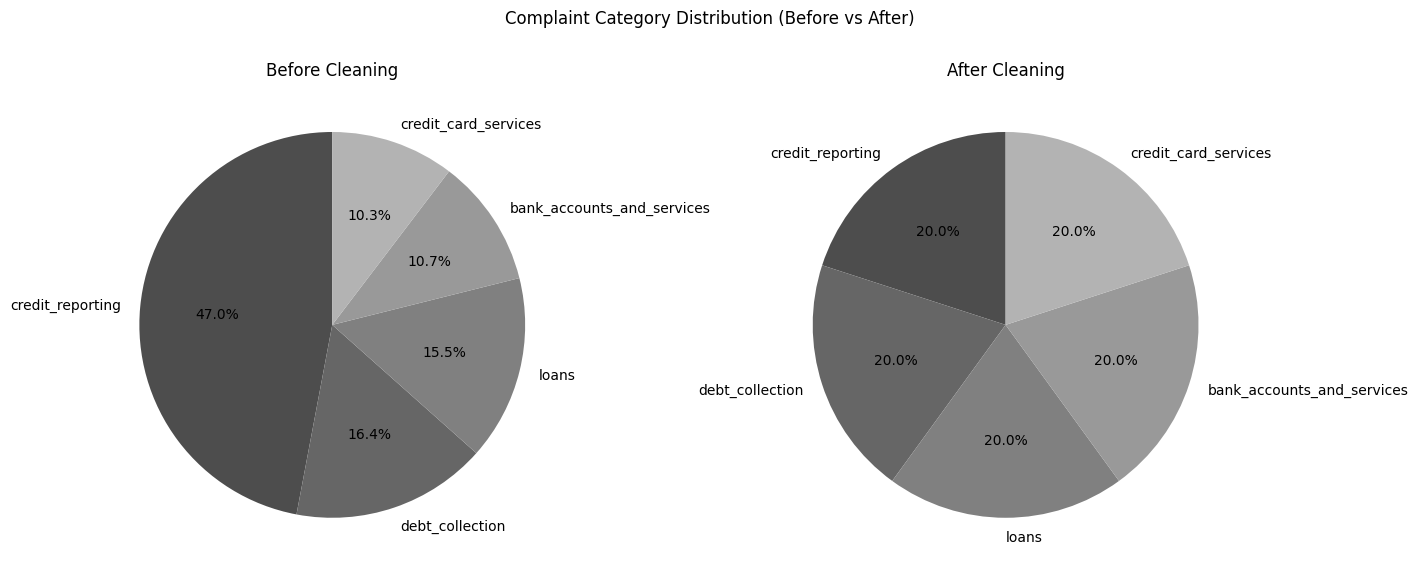

In [ ]:
before_counts = df['label'].value_counts()
after_counts = df_balanced['label'].value_counts()

labels = before_counts.index  
colors = ['#4d4d4d', '#666666', '#808080', '#999999', '#b3b3b3']

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].pie(
    before_counts,
    labels=labels,             
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axs[0].set_title("Before Cleaning")

axs[1].pie(
    after_counts,
    labels=labels,           
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axs[1].set_title("After Cleaning")
plt.suptitle("Complaint Category Distribution (Before vs After)")
plt.tight_layout()
plt.show()